# XAI vs No XAI Comparison (Quercetin)

Comparing the effect of explainable AI (XAI) guidance on molecule optimization performance for Claude Opus 4.5 on the Quercetin similarity + QED task with two different target thresholds (0.75 and 0.8).

In [43]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [44]:
# Define paths
RESULTS_DIR = Path("../../data/results/similarity_qed_quercetin")

# Define experiment groups: (display_name, folder_name)
GROUPS = [
    ("Claude Opus 4.5 (XAI, 0.75)", "claude-opus-4.5_full_xai_0.75"),
    ("Claude Opus 4.5 (No XAI, 0.75)", "claude-opus-4.5_no_xai_0.75"),
    ("Claude Opus 4.5 (XAI, 0.8)", "claude-opus-4.5_full_xai_0.8"),
    ("Claude Opus 4.5 (Partial XAI, 0.8)", "claude-opus-4.5_partial_xai_0.8"),
    ("Claude Opus 4.5 (No XAI, 0.8)", "claude-opus-4.5_no_xai_0.8"),
    ("Claude Opus 4.5 (No XAI, no description, 0.8)", "claude-opus-4.5_no_description_0.8"),
]

## Loading Data

In [45]:
def load_trace(p: Path) -> list:
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d


def load_results_as_df(results_dir: Path, groups: list) -> pd.DataFrame:
    """Load all results from JSON trace files into a DataFrame.
    
    Returns DataFrame with columns: model, replicate, iteration, score, smiles
    """
    rows = []
    
    for display_name, folder_name in groups:
        folder_path = results_dir / folder_name
        files = sorted(folder_path.glob("sim_qed_relevant_*.json"))
        
        if not files:
            raise FileNotFoundError(f"No files in {folder_path} matching sim_qed_relevant_*.json")
        
        for file_path in files:
            # Extract replicate (e.g., "rep1", "rep2") from filename
            rep_match = re.search(r'rep(\d+)', file_path.name)
            replicate = f"rep{rep_match.group(1)}" if rep_match else "unknown"
            
            try:
                trace = load_trace(file_path)
                for entry in trace:
                    rows.append({
                        "model": display_name,
                        "replicate": replicate,
                        "iteration": int(entry["iteration"]),
                        "score": float(entry["score"]),
                        "smiles": entry["smiles"],
                    })
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return pd.DataFrame(rows)


# Load all results
df = load_results_as_df(RESULTS_DIR, GROUPS)
print(f"Loaded {len(df)} rows from {df['model'].nunique()} model configurations")
print(f"Replicates: {df['replicate'].nunique()}")
print(f"\nRows per model:")
print(df.groupby('model').size())
df.head(10)

Loaded 583 rows from 6 model configurations
Replicates: 5

Rows per model:
model
Claude Opus 4.5 (No XAI, 0.75)                    24
Claude Opus 4.5 (No XAI, 0.8)                     81
Claude Opus 4.5 (No XAI, no description, 0.8)    249
Claude Opus 4.5 (Partial XAI, 0.8)               155
Claude Opus 4.5 (XAI, 0.75)                       14
Claude Opus 4.5 (XAI, 0.8)                        60
dtype: int64


,model,replicate,iteration,score,smiles
0,"Claude Opus 4.5 (XAI, 0.75)",rep1,1,0.762674,O=C1c2c(O/C(=C1/O)c3ccc(OC)c(OC)c3)cc(O)cc2O
1,"Claude Opus 4.5 (XAI, 0.75)",rep1,2,0.825238,COc1ccc(C2CC(=O)c3c(O)cc(OC)cc3O2)cc1OC
2,"Claude Opus 4.5 (XAI, 0.75)",rep2,1,0.747522,O=C1c3c(O/C(=C1/O)c2ccc(OC)c(O)c2)cc(O)cc3OC
3,"Claude Opus 4.5 (XAI, 0.75)",rep2,2,0.612892,COc1ccc(/C=C/C(=O)c2ccc(OC)cc2O)cc1OC
4,"Claude Opus 4.5 (XAI, 0.75)",rep2,3,0.778494,COc1ccc(-c2cc(=O)c3c(OC)cc(OC)cc3o2)cc1O
5,"Claude Opus 4.5 (XAI, 0.75)",rep2,4,0.727395,COc1cc(OC)c2c(=O)cc(C3CCCCC3)oc2c1
6,"Claude Opus 4.5 (XAI, 0.75)",rep2,5,0.813776,O=C1CC(c2ccc(O)c(O)c2)Oc2cc(O)ccc12
7,"Claude Opus 4.5 (XAI, 0.75)",rep2,6,0.852808,O=C1CC(c2ccc(OC)c(O)c2)Oc2cc(O)ccc12
8,"Claude Opus 4.5 (XAI, 0.75)",rep3,1,0.773655,O=C1c2c(O)cc(O)cc2OC(=C1O)c3ccc(OC)cc3
9,"Claude Opus 4.5 (XAI, 0.75)",rep3,2,0.711837,O=C1c2c(OC)cc(O)cc2OC(=C1)c3ccc(F)cc3


---
## Best-so-far Progression Plot (Threshold 0.75)

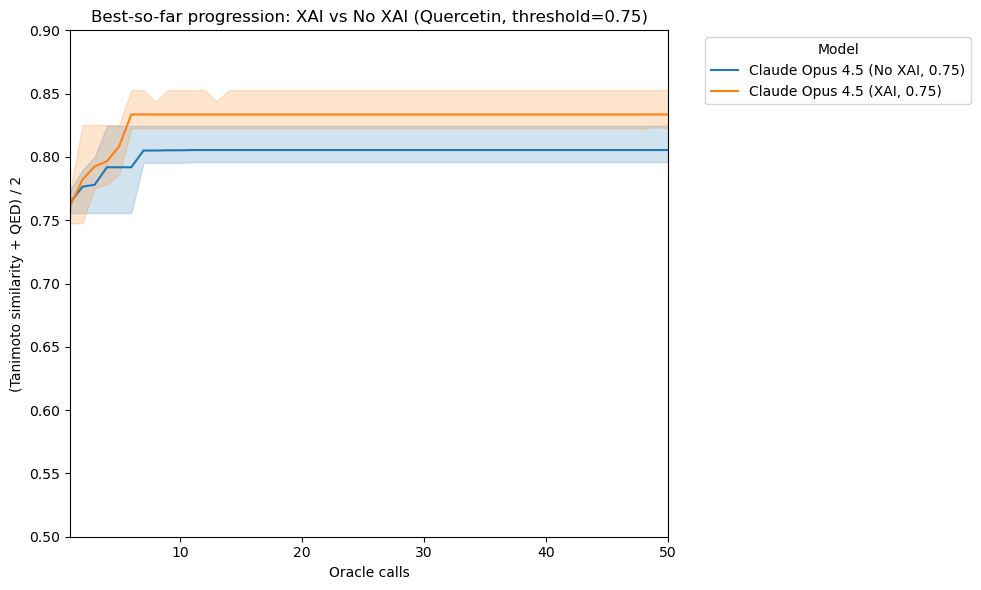

In [46]:
# Filter for 0.75 threshold experiments
df_075 = df[df["model"].str.contains("0.75")].copy()

# Compute best-so-far (cummax needs data sorted by iteration)
df_075["best_so_far"] = (
    df_075.sort_values("iteration")
    .groupby(["model", "replicate"])["score"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(1, max_iter + 1)
df_plot_075 = (
    df_075[df_075["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "replicate"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% bootstrap CI)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot_075, x="iteration", y="value", hue="model", errorbar=('ci', 95))
plt.xlabel("Oracle calls")
plt.ylabel("(Tanimoto similarity + QED) / 2")
plt.xlim(1, 50)
plt.ylim(0.5, 0.9)
plt.title("Best-so-far progression: XAI vs No XAI (Quercetin, threshold=0.75)")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## Best-so-far Progression Plot (Threshold 0.8)

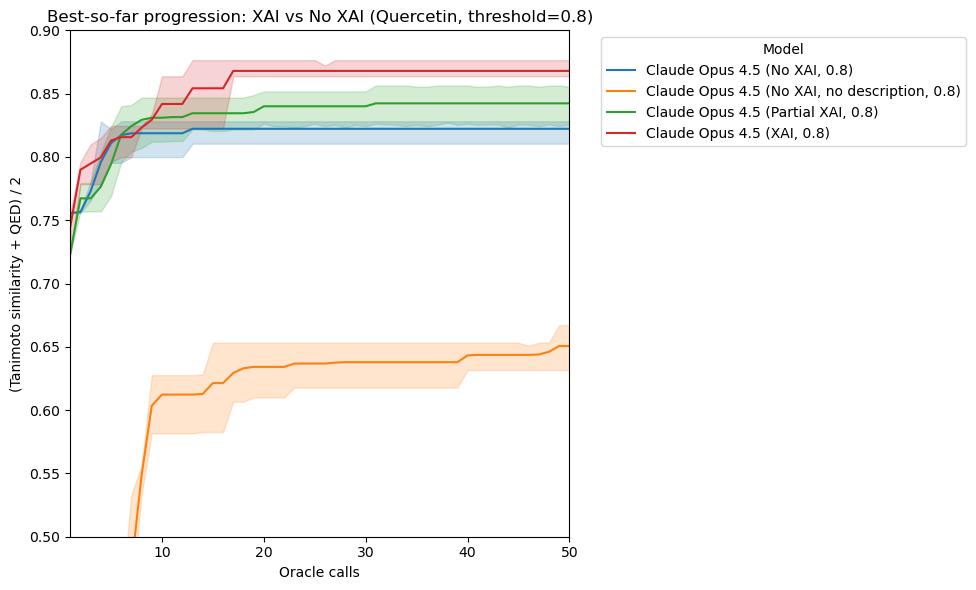

In [47]:
# Filter for 0.8 threshold experiments
df_08 = df[df["model"].str.contains("0.8")].copy()

# Compute best-so-far (cummax needs data sorted by iteration)
df_08["best_so_far"] = (
    df_08.sort_values("iteration")
    .groupby(["model", "replicate"])["score"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(1, max_iter + 1)
df_plot_08 = (
    df_08[df_08["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "replicate"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% bootstrap CI)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot_08, x="iteration", y="value", hue="model", errorbar=('ci', 95))
plt.xlabel("Oracle calls")
plt.ylabel("(Tanimoto similarity + QED) / 2")
plt.xlim(1, 50)
plt.ylim(0.5, 0.9)
plt.title("Best-so-far progression: XAI vs No XAI (Quercetin, threshold=0.8)")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## Combined Best-so-far Progression Plot (Both Thresholds)

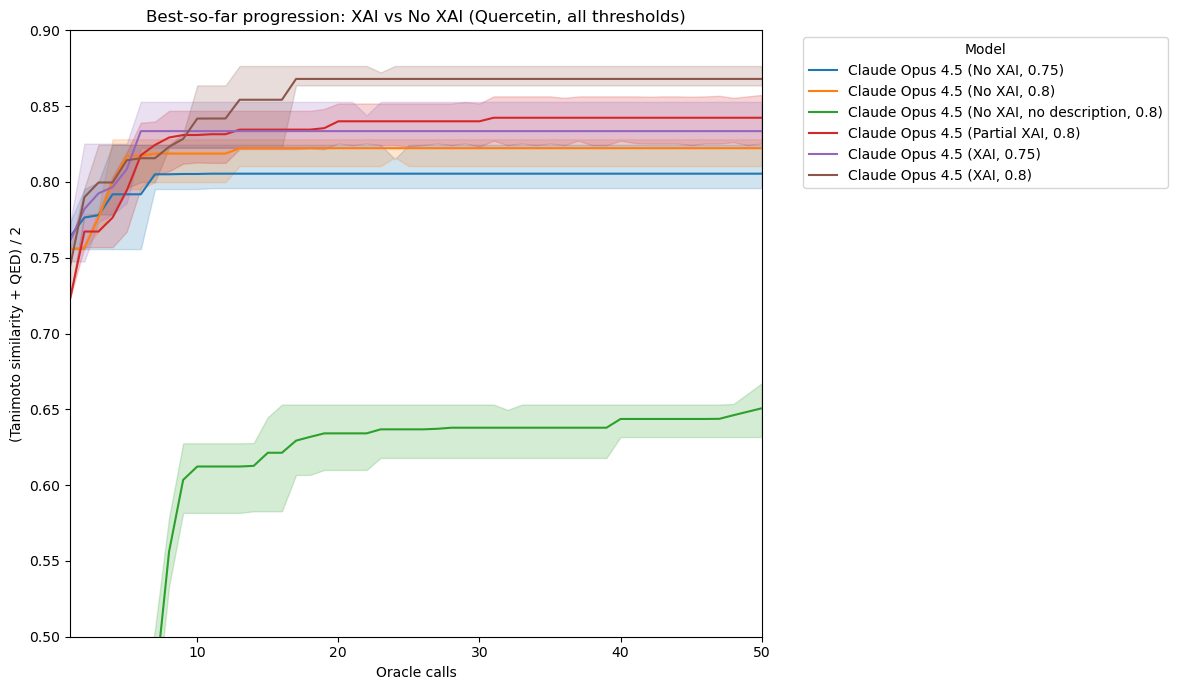

In [48]:
# Compute best-so-far for all data
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "replicate"])["score"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(1, max_iter + 1)
df_plot_all = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "replicate"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% bootstrap CI)
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_plot_all, x="iteration", y="value", hue="model", errorbar=('ci', 95))
plt.xlabel("Oracle calls")
plt.ylabel("(Tanimoto similarity + QED) / 2")
plt.xlim(1, 50)
plt.ylim(0.5, 0.9)
plt.title("Best-so-far progression: XAI vs No XAI (Quercetin, all thresholds)")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## Iteration to Reach Threshold

In [49]:
def first_iteration_above_threshold(group, threshold):
    """Return first iteration where best_so_far >= threshold, or NaN if never reached."""
    above = group[group["best_so_far"] >= threshold]
    if len(above) > 0:
        return above["iteration"].min()
    return np.nan


def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) == 0:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,), 
        statistic=np.mean, 
        n_resamples=n_bootstrap, 
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high


# Compute for threshold 0.75
THRESHOLD_075 = 0.75
iter_to_threshold_075 = (
    df_075
    .groupby(["model", "replicate"])
    .apply(lambda g: first_iteration_above_threshold(g, THRESHOLD_075), include_groups=False)
    .reset_index(name=f"iter_to_{THRESHOLD_075}")
)

# Summarize by model with bootstrap CI
summary_rows_075 = []
for model, group in iter_to_threshold_075.groupby("model"):
    values = group[f"iter_to_{THRESHOLD_075}"]
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    # Compute distances from mean to CI bounds
    ci_low_dist = mean_val - ci_low  # Distance below mean
    ci_high_dist = ci_high - mean_val  # Distance above mean
    n_total = len(values)
    never_reached = values.isna().sum()
    success_rate = (n_total - never_reached) / n_total * 100
    summary_rows_075.append({
        "Model": model,
        "Mean Iteration": mean_val,
        "CI 95% -": ci_low_dist,
        "CI 95% +": ci_high_dist,
        "N": n_total,
        "Never Reached": never_reached,
        "Success Rate (%)": success_rate
    })

threshold_summary_075 = pd.DataFrame(summary_rows_075).set_index("Model").round(2)

print(f"Iteration to reach {THRESHOLD_075} threshold (best-so-far) with 95% Bootstrap CI")
threshold_summary_075

Iteration to reach 0.75 threshold (best-so-far) with 95% Bootstrap CI


/Users/fabian/.local/share/mamba/envs/bayer/lib/python3.13/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/fabian/.local/share/mamba/envs/bayer/lib/python3.13/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


,Mean Iteration,CI 95% -,CI 95% +,N,Never Reached,Success Rate (%)
Model,,,,,,
"Claude Opus 4.5 (No XAI, 0.75)",1.00,NaN,NaN,3,0,100.0
"Claude Opus 4.5 (XAI, 0.75)",1.67,0.67,1.33,3,0,100.0


In [50]:
# Compute for threshold 0.8
THRESHOLD_08 = 0.8
iter_to_threshold_08 = (
    df_08
    .groupby(["model", "replicate"])
    .apply(lambda g: first_iteration_above_threshold(g, THRESHOLD_08), include_groups=False)
    .reset_index(name=f"iter_to_{THRESHOLD_08}")
)

# Summarize by model with bootstrap CI
summary_rows_08 = []
for model, group in iter_to_threshold_08.groupby("model"):
    values = group[f"iter_to_{THRESHOLD_08}"]
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    # Compute distances from mean to CI bounds
    ci_low_dist = mean_val - ci_low  # Distance below mean
    ci_high_dist = ci_high - mean_val  # Distance above mean
    n_total = len(values)
    never_reached = values.isna().sum()
    success_rate = (n_total - never_reached) / n_total * 100
    summary_rows_08.append({
        "Model": model,
        "Mean Iteration": mean_val,
        "CI 95% -": ci_low_dist,
        "CI 95% +": ci_high_dist,
        "N": n_total,
        "Never Reached": never_reached,
        "Success Rate (%)": success_rate
    })

threshold_summary_08 = pd.DataFrame(summary_rows_08).set_index("Model").round(2)

print(f"Iteration to reach {THRESHOLD_08} threshold (best-so-far) with 95% Bootstrap CI")
threshold_summary_08

Iteration to reach 0.8 threshold (best-so-far) with 95% Bootstrap CI


,Mean Iteration,CI 95% -,CI 95% +,N,Never Reached,Success Rate (%)
Model,,,,,,
"Claude Opus 4.5 (No XAI, 0.8)",7.33,3.00,5.67,3,0,100.0
"Claude Opus 4.5 (No XAI, no description, 0.8)",NaN,NaN,NaN,3,3,0.0
"Claude Opus 4.5 (Partial XAI, 0.8)",7.00,2.00,4.20,5,0,100.0
"Claude Opus 4.5 (XAI, 0.8)",5.33,2.33,2.67,3,0,100.0


---
## AUC Top-1 over 50 Iterations

In [51]:
def compute_auc_top1(group_df, max_oracle_calls=50):
    """Compute AUC of top-1 (best) score vs oracle calls from a dataframe group.
    
    Args:
        group_df: DataFrame with 'score' and 'iteration' columns for a single run
        max_oracle_calls: Maximum number of oracle calls (default 50)
    
    Returns:
        AUC value normalized to [0, 1]
    """
    sorted_df = group_df.sort_values('iteration')
    
    best_score = 0.0
    best_at_call = {}
    
    for _, row in sorted_df.iterrows():
        oracle_call = int(row['iteration'])
        score = float(row['score'])
        
        if oracle_call > max_oracle_calls:
            break
        
        if score > best_score:
            best_score = score
        
        best_at_call[oracle_call] = best_score
    
    oracle_calls = sorted(best_at_call.keys())
    
    # Compute AUC as sum of rectangles
    auc = 0.0
    prev_call = 0
    prev_best = 0.0
    
    for call in oracle_calls:
        auc += prev_best * (call - prev_call)
        prev_call = call
        prev_best = best_at_call[call]
    
    # Extend to max_oracle_calls
    auc += prev_best * (max_oracle_calls - prev_call)
    
    return auc / max_oracle_calls


# Compute AUC Top-1 for each model/replicate
MAX_ORACLE_CALLS = 50

auc_records = []
for (model, replicate), group in df.groupby(['model', 'replicate']):
    auc = compute_auc_top1(group, MAX_ORACLE_CALLS)
    auc_records.append({
        'model': model,
        'replicate': replicate,
        'auc_top1': auc
    })

auc_df = pd.DataFrame(auc_records)

# Summarize by model with bootstrap CI
auc_summary_rows = []
for model, group in auc_df.groupby('model'):
    values = group['auc_top1']
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    # Compute distances from mean to CI bounds
    ci_low_dist = mean_val - ci_low  # Distance below mean
    ci_high_dist = ci_high - mean_val  # Distance above mean
    auc_summary_rows.append({
        "Model": model,
        "Mean AUC Top-1": mean_val,
        "CI 95% -": ci_low_dist,
        "CI 95% +": ci_high_dist,
        "N": len(values),
    })

auc_summary = pd.DataFrame(auc_summary_rows).set_index("Model").round(3)

print(f"AUC Top-1 over {MAX_ORACLE_CALLS} iterations with 95% Bootstrap CI")
auc_summary

AUC Top-1 over 50 iterations with 95% Bootstrap CI


,Mean AUC Top-1,CI 95% -,CI 95% +,N
Model,,,,
"Claude Opus 4.5 (No XAI, 0.75)",0.787,0.010,0.019,3
"Claude Opus 4.5 (No XAI, 0.8)",0.801,0.012,0.006,3
"Claude Opus 4.5 (No XAI, no description, 0.8)",0.590,0.018,0.010,3
"Claude Opus 4.5 (Partial XAI, 0.8)",0.814,0.016,0.010,5
"Claude Opus 4.5 (XAI, 0.75)",0.812,0.011,0.015,3
"Claude Opus 4.5 (XAI, 0.8)",0.836,0.006,0.009,3
